# PT Transfer Synchronism Analysis

This notebook analyzes transfer synchronism for travelers who use at least two PT legs in the same trip.
For each transfer, it computes:
- transfer time (arrival of PT leg $i$ to departure of PT leg $i+1$)
- walking time between PT legs
- waiting time between PT legs
- walking distance between PT legs

In [16]:
from pathlib import Path
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd

analysis_dir = Path.cwd()
if not (analysis_dir / 'pt_transfer_analysis.py').exists():
    analysis_dir = Path.cwd() / 'Analysis'

if str(analysis_dir) not in sys.path:
    sys.path.append(str(analysis_dir))

import pt_transfer_analysis
importlib.reload(pt_transfer_analysis)

from pt_transfer_analysis import analyze_pt_transfer_synchronism, add_realistic_transfer_estimates, seconds_to_hhmmss

In [2]:
candidate_paths = [
    Path('Simulation/output/output_legs.csv'),
    Path('../Simulation/output/output_legs.csv'),
]

legs_path = None
for p in candidate_paths:
    if p.exists():
        legs_path = p
        break

if legs_path is None:
    raise FileNotFoundError('Could not find output_legs.csv.gz from this notebook location.')

result = analyze_pt_transfer_synchronism(legs_path, transfer_modes=('walk',))
transfers = result.transfers
person_summary = result.person_summary
trip_summary = result.trip_summary
global_summary = result.global_summary

print(f'Legs source: {legs_path}')
print(f'Transfer events found: {len(transfers):,}')
print(f'Agents with transfers: {global_summary["n_agents_with_transfers"]:,}')

Legs source: ../Simulation/output/output_legs.csv
Transfer events found: 73,563
Agents with transfers: 38,732


In [3]:
summary_view = pd.Series(global_summary, name='value').to_frame()
summary_view.loc['mean_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['mean_transfer_time_s'])
summary_view.loc['median_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['median_transfer_time_s'])
summary_view.loc['p95_transfer_time_hhmmss'] = seconds_to_hhmmss(global_summary['p95_transfer_time_s'])
summary_view

,value
n_agents_with_transfers,38732.0
n_trips_with_transfers,58313.0
n_transfer_events,73563.0
mean_transfer_time_s,44.491348
median_transfer_time_s,24.0
p95_transfer_time_s,139.0
mean_transfer_distance_m,43.049155
median_transfer_distance_m,32.0
p95_transfer_distance_m,120.0
total_transfer_time_s,3272917.0


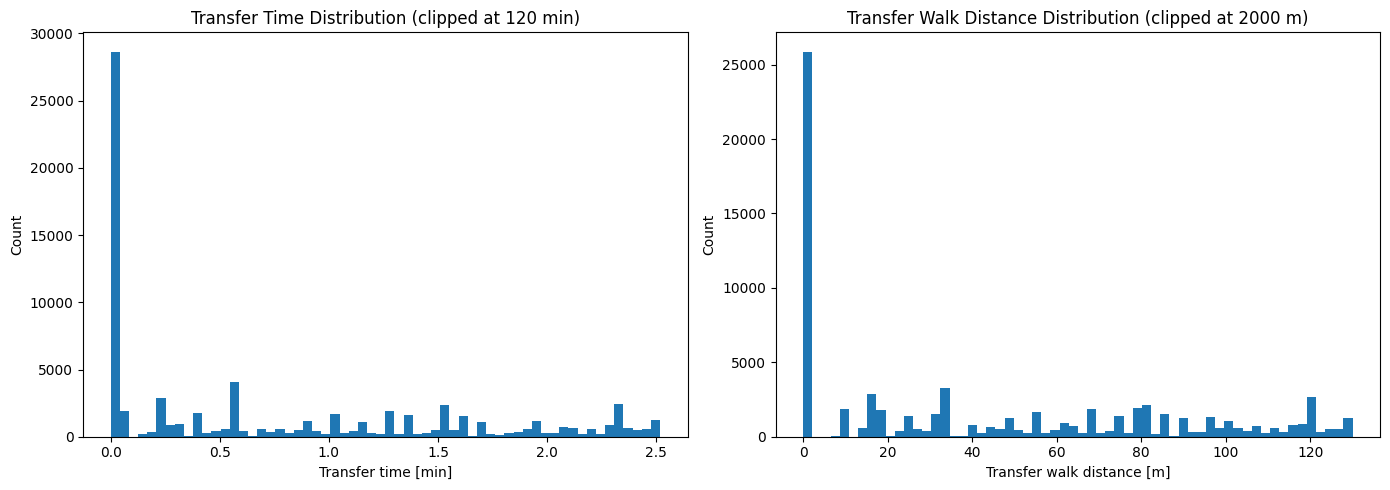

In [4]:
transfers = transfers.copy()
transfers['transfer_time_min'] = transfers['transfer_time_s'] / 60.0
transfers['transfer_distance_m'] = transfers['transfer_distance_m'].astype(float)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(transfers['transfer_time_min'].clip(upper=120), bins=60)
axes[0].set_title('Transfer Time Distribution (clipped at 120 min)')
axes[0].set_xlabel('Transfer time [min]')
axes[0].set_ylabel('Count')

axes[1].hist(transfers['transfer_distance_m'].clip(upper=2000), bins=60)
axes[1].set_title('Transfer Walk Distance Distribution (clipped at 2000 m)')
axes[1].set_xlabel('Transfer walk distance [m]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [5]:
top_transfers = transfers.sort_values(['transfer_time_s', 'transfer_distance_m'], ascending=False).head(20)
top_people = person_summary.sort_values(['n_transfers', 'total_transfer_time_s'], ascending=False).head(20)
top_trips = trip_summary.sort_values(['n_transfers', 'trip_transfer_time_s'], ascending=False).head(20)

display(top_transfers)
display(top_people)
display(top_trips)

,person,trip_id,pt_legs_in_trip,transfer_index,prev_pt_dep_time,prev_pt_arrival_time,next_pt_dep_time,transfer_time_s,transfer_walk_time_s,transfer_wait_time_s,transfer_distance_m,legs_between_count,modes_between,prev_transit_line,prev_transit_route,next_transit_line,next_transit_route,prev_egress_stop_id,next_access_stop_id,transfer_time_min
19,person_100069__men__70_to_74_years__1_basic__u...,person_100069__men__70_to_74_years__1_basic__u...,3,2,18:49:26,19:16:00,19:18:31,151.0,151.0,0.0,130.0,1,walk,705,705_1_F_52,205,205_0_F_174,ASPL1.link:373231,IPO5.link:387375,2.516667
494,person_101289__men__45_to_49_years__undergradu...,person_101289__men__45_to_49_years__undergradu...,3,2,10:54:27,13:56:47,13:59:18,151.0,151.0,0.0,130.0,1,walk,601,601_1_F_2,200,200_0_F_18,PRG2.link:2702,PRG4.link:121643,2.516667
618,person_101661__men__30_to_34_years__undergradu...,person_101661__men__30_to_34_years__undergradu...,3,2,12:15:02,13:14:03,13:16:34,151.0,151.0,0.0,130.0,1,walk,705,705_1_F_6,205,205_0_F_66,ASPL1.link:373231,IPO5.link:387375,2.516667
1029,person_102616__men__30_to_34_years__3_basic__w...,person_102616__men__30_to_34_years__3_basic__w...,2,1,18:34:12,19:15:59,19:18:30,151.0,151.0,0.0,130.0,1,walk,705,705_1_F_52,704,704_1_F_58,ASPL1.link:373231,IPO5.link:387375,2.516667
1074,person_102691__men__45_to_49_years__no_educati...,person_102691__men__45_to_49_years__no_educati...,3,2,08:27:53,09:25:09,09:27:40,151.0,151.0,0.0,130.0,1,walk,705,705_1_F_34,704,704_1_F_61,ASPL1.link:373231,IPO5.link:387375,2.516667
1202,person_103175__men__45_to_49_years__3_basic__w...,person_103175__men__45_to_49_years__3_basic__w...,2,1,11:49:36,12:13:25,12:15:56,151.0,151.0,0.0,130.0,1,walk,303,303_0_F_8,508,508_0_F_54,CZV4.link:379905,CZV1.link:164359,2.516667
1744,person_104743__men__45_to_49_years__undergradu...,person_104743__men__45_to_49_years__undergradu...,2,1,11:02:23,12:08:02,12:10:33,151.0,151.0,0.0,130.0,1,walk,705,705_1_F_6,205,205_0_F_66,ASPL1.link:373231,IPO5.link:387375,2.516667
1829,person_104988__men__35_to_39_years__3_basic__r...,person_104988__men__35_to_39_years__3_basic__r...,3,2,13:44:29,14:34:03,14:36:34,151.0,151.0,0.0,130.0,1,walk,705,705_1_F_6,205,205_0_F_124,ASPL1.link:373231,IPO5.link:387375,2.516667
1870,person_10508__men__50_to_54_years__3_basic__wo...,person_10508__men__50_to_54_years__3_basic__wo...,3,2,20:40:13,22:09:05,22:11:36,151.0,151.0,0.0,130.0,1,walk,704,704_1_F_41,600,600_0_F_155,AZ.link:89066,AML1.link:89059,2.516667
1947,person_105238__men__60_to_64_years__highschool...,person_105238__men__60_to_64_years__highschool...,2,1,12:15:37,22:14:19,22:16:50,151.0,151.0,0.0,130.0,1,walk,208,208_1_F_9,207,207_0_F_60,PRG2.link:2702,PRG4.link:121643,2.516667


,person,n_trips_with_transfers,n_transfers,total_transfer_time_s,total_transfer_wait_time_s,total_transfer_walk_time_s,total_transfer_distance_m,mean_transfer_time_s,mean_transfer_distance_m
1015,person_10547__men__55_to_59_years__highschool_...,4,9,520.0,0.0,520.0,473,57.777778,52.555556
5171,person_128216__women__35_to_39_years__3_basic_...,4,9,453.0,0.0,453.0,403,50.333333,44.777778
7913,person_14318__men__65_to_69_years__no_educatio...,4,9,296.0,0.0,296.0,334,32.888889,37.111111
11315,person_160958__women__40_to_44_years__2_basic_...,4,8,646.0,0.0,646.0,568,80.750000,71.000000
33350,person_71508__men__55_to_59_years__1_basic__un...,4,8,635.0,0.0,635.0,560,79.375000,70.000000
23346,person_226560__women__40_to_44_years__undergra...,4,8,599.0,0.0,599.0,528,74.875000,66.000000
33543,person_72520__men__25_to_29_years__1_basic__wo...,3,8,560.0,0.0,560.0,496,70.000000,62.000000
31220,person_59926__men__45_to_49_years__1_basic__in...,4,8,557.0,0.0,557.0,493,69.625000,61.625000
25501,person_29917__men__75_plus_years__1_basic__wor...,3,8,537.0,0.0,537.0,475,67.125000,59.375000
14575,person_178814__women__60_to_64_years__highscho...,5,8,506.0,0.0,506.0,448,63.250000,56.000000


,person,trip_id,n_transfers,trip_transfer_time_s,trip_transfer_wait_time_s,trip_transfer_walk_time_s,trip_transfer_distance_m
55704,person_90139__men__60_to_64_years__no_educatio...,person_90139__men__60_to_64_years__no_educatio...,5,129.0,0.0,129.0,121
31274,person_211167__women__40_to_44_years__3_basic_...,person_211167__women__40_to_44_years__3_basic_...,4,408.0,0.0,408.0,357
11178,person_140698__women__75_plus_years__2_basic__...,person_140698__women__75_plus_years__2_basic__...,4,379.0,0.0,379.0,329
39345,person_33213__men__65_to_69_years__highschool_...,person_33213__men__65_to_69_years__highschool_...,4,379.0,0.0,379.0,329
21988,person_179177__women__30_to_34_years__3_basic_...,person_179177__women__30_to_34_years__3_basic_...,4,375.0,0.0,375.0,330
11732,person_14296__men__60_to_64_years__1_basic__in...,person_14296__men__60_to_64_years__1_basic__in...,4,363.0,0.0,363.0,319
30511,person_208733__women__55_to_59_years__3_basic_...,person_208733__women__55_to_59_years__3_basic_...,4,331.0,0.0,331.0,289
23020,person_182837__women__55_to_59_years__no_educa...,person_182837__women__55_to_59_years__no_educa...,4,300.0,0.0,300.0,263
48780,person_66481__men__35_to_39_years__no_educatio...,person_66481__men__35_to_39_years__no_educatio...,4,298.0,0.0,298.0,261
36685,person_23480__men__20_to_24_years__2_basic__wo...,person_23480__men__20_to_24_years__2_basic__wo...,4,294.0,0.0,294.0,262


In [6]:
output_dir = Path('Analysis/plots') if Path('Analysis/plots').exists() else Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)

transfers.to_csv(output_dir / 'pt_transfer_events.csv', index=False)
person_summary.to_csv(output_dir / 'pt_transfer_person_summary.csv', index=False)
trip_summary.to_csv(output_dir / 'pt_transfer_trip_summary.csv', index=False)

print(f'Saved outputs to: {output_dir.resolve()}')

Saved outputs to: /home/iohan/Documentos/FEUP/Thesis/OpenOPorto/Analysis/plots


## Transfer Routes Analysis
Analysis of the most common PT line-to-line transfers, stops, and wait times.

In [7]:
# Most common PT line-to-line transfers
# Create a transfer route identifier (line_x -> line_y)
transfers_analysis = transfers.copy()
transfers_analysis['transfer_route'] = (
    transfers_analysis['prev_transit_line'].astype(str) + 
    ' → ' + 
    transfers_analysis['next_transit_line'].astype(str)
)

# Count transfers by route and get statistics
line_transfers = transfers_analysis.groupby('transfer_route', as_index=False).agg({
    'transfer_time_s': ['count', 'mean', 'median', 'min', 'max'],
    'transfer_wait_time_s': ['mean', 'median', 'max'],
    'transfer_walk_time_s': ['mean', 'sum'],
    'transfer_distance_m': ['mean', 'sum'],
}).round(2)

# Flatten column names
line_transfers.columns = ['_'.join(col).strip('_') for col in line_transfers.columns.values]
line_transfers.columns = ['transfer_route', 'count', 'mean_transfer_time_s', 'median_transfer_time_s', 
                          'min_transfer_time_s', 'max_transfer_time_s',
                          'mean_wait_time_s', 'median_wait_time_s', 'max_wait_time_s',
                          'mean_walk_time_s', 'total_walk_time_s',
                          'mean_distance_m', 'total_distance_m']

# Sort by frequency
line_transfers = line_transfers.sort_values('count', ascending=False)

print("\n=== Top 30 Most Common PT Line-to-Line Transfers ===")
print(f"Total unique transfer routes: {len(line_transfers)}")
print(f"\nTop transfers (showing count, mean transfer time, mean wait time):\n")
display(line_transfers[['transfer_route', 'count', 'mean_transfer_time_s', 'mean_wait_time_s', 'mean_distance_m']].head(30))


=== Top 30 Most Common PT Line-to-Line Transfers ===
Total unique transfer routes: 2038

Top transfers (showing count, mean transfer time, mean wait time):



,transfer_route,count,mean_transfer_time_s,mean_wait_time_s,mean_distance_m
1922,C → D,1526,0.00,0.0,0.00
1935,D → 500,1526,35.00,0.0,33.00
2036,F → D,1150,0.00,0.0,0.00
1959,D → C,1084,0.00,0.0,0.00
1851,B → D,950,0.00,0.0,0.00
1961,D → F,884,0.00,0.0,0.00
1999,E → D,739,0.00,0.0,0.00
1886,Bexp → D,721,0.00,0.0,0.00
1957,D → B,703,0.00,0.0,0.00
1960,D → E,648,0.00,0.0,0.00


In [8]:
# Most common stop-to-stop transfers
transfers_analysis['transfer_stop'] = (
    transfers_analysis['prev_egress_stop_id'].astype(str) + 
    ' → ' + 
    transfers_analysis['next_access_stop_id'].astype(str)
)

stop_transfers = transfers_analysis.groupby('transfer_stop', as_index=False).agg({
    'transfer_time_s': ['count', 'mean', 'median'],
    'transfer_wait_time_s': ['mean', 'median', 'max'],
    'transfer_walk_time_s': 'mean',
    'transfer_distance_m': 'mean',
}).round(2)

stop_transfers.columns = ['_'.join(col).strip('_') for col in stop_transfers.columns.values]
stop_transfers.columns = ['transfer_stop', 'count', 'mean_transfer_time_s', 'median_transfer_time_s',
                          'mean_wait_time_s', 'median_wait_time_s', 'max_wait_time_s',
                          'mean_walk_time_s', 'mean_distance_m']
stop_transfers = stop_transfers.sort_values('count', ascending=False)

print("\n=== Top 30 Most Common Stop-to-Stop Transfers ===")
print(f"Total unique stop pairs: {len(stop_transfers)}")
print(f"\nTop stop transfers (showing count, mean transfer time, mean wait time):\n")
display(stop_transfers[['transfer_stop', 'count', 'mean_transfer_time_s', 'mean_wait_time_s', 'mean_distance_m']].head(30))


=== Top 30 Most Common Stop-to-Stop Transfers ===
Total unique stop pairs: 1589

Top stop transfers (showing count, mean transfer time, mean wait time):



,transfer_stop,count,mean_transfer_time_s,mean_wait_time_s,mean_distance_m
103,5726.link:pt_5726 → 5726.link:pt_5726,9269,0.0,0.0,0.0
64,5697.link:pt_5697 → C24A1.link:214971,1813,5.0,0.0,9.0
147,5778.link:pt_5778 → 1SBNT.link:417428,1526,35.0,0.0,33.0
1529,TRD5.link:136702 → 5726.link:pt_5726,1272,0.0,0.0,96.0
77,5706.link:pt_5706 → BCM2.link:144854,1221,139.0,0.0,120.0
65,5697.link:pt_5697 → C24A2.link:402105,1147,77.0,0.0,68.0
312,BCM2.link:144854 → 5706.link:pt_5706,1145,139.0,0.0,120.0
1577,VIS5.link:189831 → 5729.link:pt_5729,1100,15.0,0.0,17.0
110,5729.link:pt_5729 → VIS5.link:189831,1096,15.0,0.0,17.0
419,C24A3.link:139831 → 5697.link:pt_5697,1007,61.0,0.0,55.0


In [9]:
# Transfers with longest wait times
# Top 30 individual transfer events with highest wait times
longest_wait = transfers_analysis[[
    'person', 'trip_id', 'transfer_route', 'transfer_stop', 
    'prev_pt_arrival_time', 'next_pt_dep_time',
    'transfer_time_s', 'transfer_wait_time_s', 'transfer_walk_time_s',
    'transfer_distance_m'
]].copy()

longest_wait['transfer_time_min'] = longest_wait['transfer_time_s'] / 60
longest_wait['transfer_wait_time_min'] = longest_wait['transfer_wait_time_s'] / 60
longest_wait['transfer_walk_time_min'] = longest_wait['transfer_walk_time_s'] / 60

longest_wait = longest_wait.sort_values('transfer_wait_time_s', ascending=False)

print("\n=== Top 50 Individual Transfers with Longest Wait Times ===")
print(f"Mean wait time across all transfers: {transfers_analysis['transfer_wait_time_s'].mean():.1f}s ({transfers_analysis['transfer_wait_time_s'].mean()/60:.1f} min)")
print(f"Median wait time: {transfers_analysis['transfer_wait_time_s'].median():.1f}s ({transfers_analysis['transfer_wait_time_s'].median()/60:.1f} min)")
print(f"95th percentile wait time: {transfers_analysis['transfer_wait_time_s'].quantile(0.95):.1f}s ({transfers_analysis['transfer_wait_time_s'].quantile(0.95)/60:.1f} min)")
print(f"\n")

display(longest_wait[[
    'transfer_route', 'transfer_wait_time_min', 'transfer_time_min', 
    'transfer_walk_time_min', 'transfer_distance_m'
]].head(50))


=== Top 50 Individual Transfers with Longest Wait Times ===
Mean wait time across all transfers: 0.0s (0.0 min)
Median wait time: 0.0s (0.0 min)
95th percentile wait time: 0.0s (0.0 min)




,transfer_route,transfer_wait_time_min,transfer_time_min,transfer_walk_time_min,transfer_distance_m
73562,402 → 502,0.0,0.000000,0.000000,0.0
0,201 → 403,0.0,0.000000,0.000000,0.0
1,205 → 704,0.0,1.383333,1.383333,74.0
2,704 → 701,0.0,0.000000,0.000000,0.0
3,Bexp → D,0.0,0.000000,0.000000,0.0
4,504 → F,0.0,2.283333,2.283333,119.0
5,403 → 501,0.0,0.000000,0.000000,0.0
6,403 → 208,0.0,0.000000,0.000000,0.0
7,201 → F,0.0,0.250000,0.250000,17.0
8,F → 400,0.0,1.633333,1.633333,86.0


In [10]:
# Transfer routes with longest average wait times
line_wait_times = transfers_analysis.groupby('transfer_route', as_index=False).agg({
    'transfer_wait_time_s': ['count', 'mean', 'median', 'max', 'std'],
    'transfer_time_s': 'mean',
    'transfer_walk_time_s': 'mean',
}).round(2)

line_wait_times.columns = ['_'.join(col).strip('_') for col in line_wait_times.columns.values]
line_wait_times.columns = ['transfer_route', 'transfer_count', 'mean_wait_s', 'median_wait_s', 
                           'max_wait_s', 'std_wait_s', 'mean_transfer_time_s', 'mean_walk_time_s']

# Convert to minutes for display
line_wait_times['mean_wait_min'] = (line_wait_times['mean_wait_s'] / 60).round(1)
line_wait_times['median_wait_min'] = (line_wait_times['median_wait_s'] / 60).round(1)
line_wait_times['max_wait_min'] = (line_wait_times['max_wait_s'] / 60).round(1)

# Sort by mean wait time
line_wait_times_sorted = line_wait_times.sort_values('mean_wait_s', ascending=False)

print("\n=== PT Line-to-Line Transfers Sorted by Average Wait Time ===")
print(f"(showing routes with at least 10 transfers)\n")

# Filter routes with at least 10 transfers for meaningful statistics
significant_routes = line_wait_times_sorted[line_wait_times_sorted['transfer_count'] >= 10]
display(significant_routes[[
    'transfer_route', 'transfer_count', 'mean_wait_min', 'median_wait_min', 'max_wait_min'
]].head(30))


=== PT Line-to-Line Transfers Sorted by Average Wait Time ===
(showing routes with at least 10 transfers)



,transfer_route,transfer_count,mean_wait_min,median_wait_min,max_wait_min
5,106 → 901,279,0.0,0.0,0.0
7,107 → 400,20,0.0,0.0,0.0
8,107 → 401,19,0.0,0.0,0.0
10,107 → 404,18,0.0,0.0,0.0
11,107 → 700,17,0.0,0.0,0.0
12,107 → 800,20,0.0,0.0,0.0
13,107 → 801,29,0.0,0.0,0.0
14,107 → 806,21,0.0,0.0,0.0
16,107 → B,34,0.0,0.0,0.0
18,107 → E,17,0.0,0.0,0.0


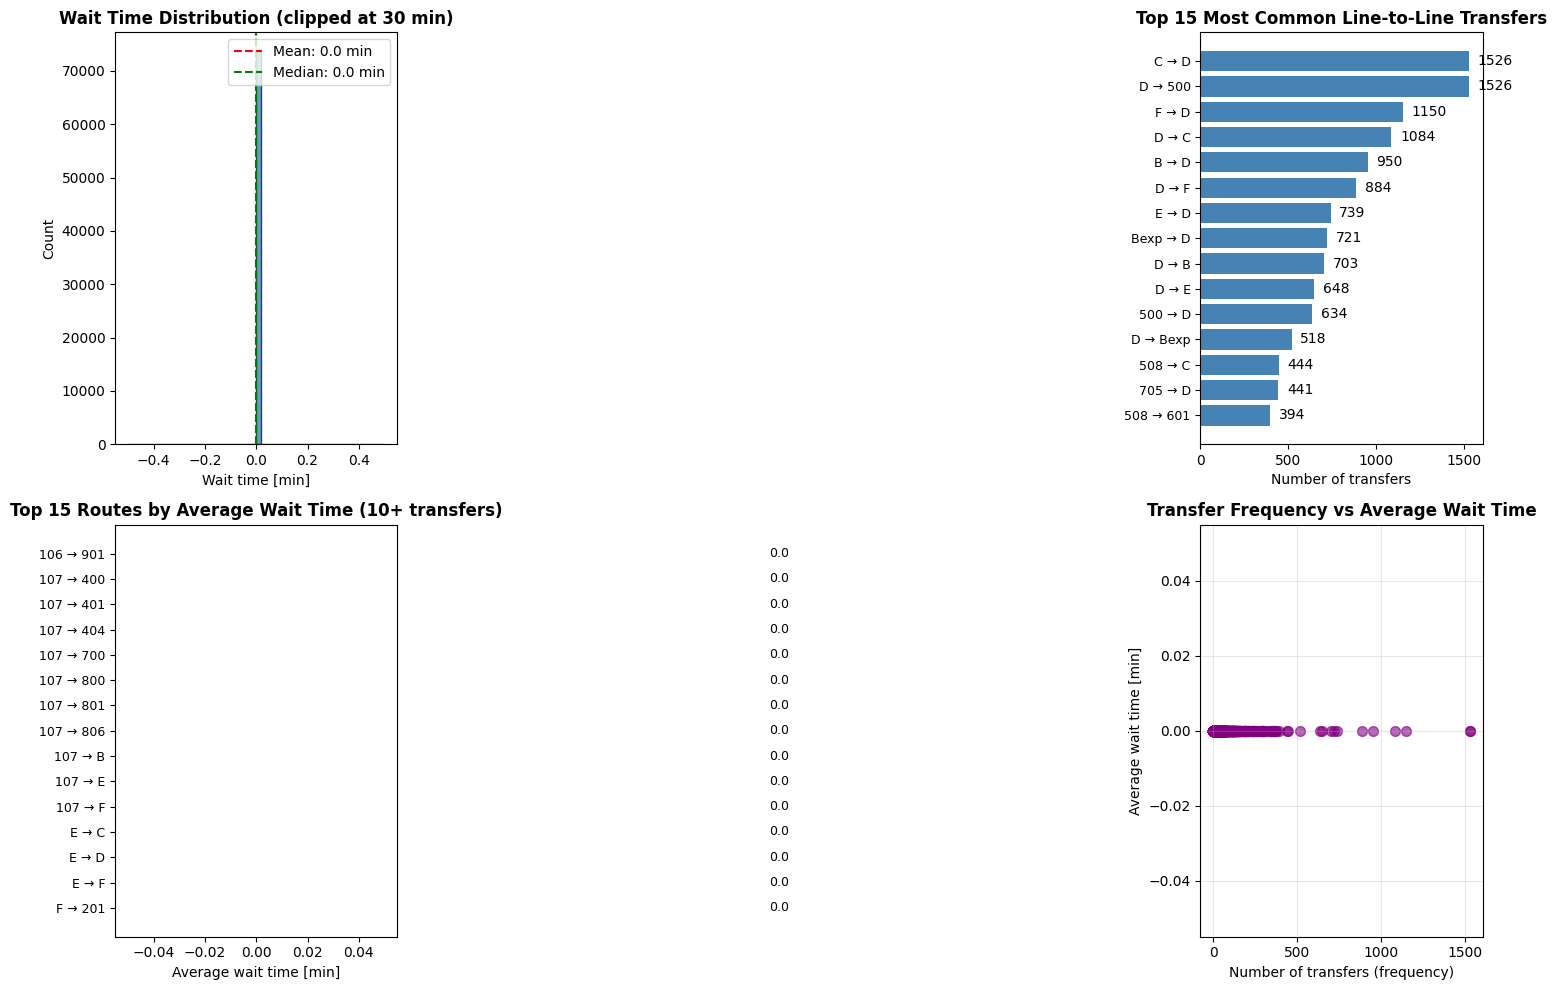

In [11]:
# Visualizations: Distribution of wait times and top transfers
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: Wait time distribution
wait_times_min = transfers_analysis['transfer_wait_time_s'] / 60
axes[0, 0].hist(wait_times_min.clip(upper=30), bins=60, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Wait Time Distribution (clipped at 30 min)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Wait time [min]')
axes[0, 0].set_ylabel('Count')
axes[0, 0].axvline(wait_times_min.mean(), color='red', linestyle='--', label=f'Mean: {wait_times_min.mean():.1f} min')
axes[0, 0].axvline(wait_times_min.median(), color='green', linestyle='--', label=f'Median: {wait_times_min.median():.1f} min')
axes[0, 0].legend()

# Plot 2: Top 15 routes by frequency
top_15_routes = line_transfers.head(15)
axes[0, 1].barh(range(len(top_15_routes)), top_15_routes['count'], color='steelblue')
axes[0, 1].set_yticks(range(len(top_15_routes)))
axes[0, 1].set_yticklabels(top_15_routes['transfer_route'], fontsize=9)
axes[0, 1].set_xlabel('Number of transfers')
axes[0, 1].set_title('Top 15 Most Common Line-to-Line Transfers', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()
for i, v in enumerate(top_15_routes['count']):
    axes[0, 1].text(v + 50, i, str(int(v)), va='center')

# Plot 3: Top 15 routes by average wait time (only routes with 10+ transfers)
top_15_wait = line_wait_times_sorted[line_wait_times_sorted['transfer_count'] >= 10].head(15)
axes[1, 0].barh(range(len(top_15_wait)), top_15_wait['mean_wait_min'], color='coral')
axes[1, 0].set_yticks(range(len(top_15_wait)))
axes[1, 0].set_yticklabels(top_15_wait['transfer_route'], fontsize=9)
axes[1, 0].set_xlabel('Average wait time [min]')
axes[1, 0].set_title('Top 15 Routes by Average Wait Time (10+ transfers)', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()
for i, v in enumerate(top_15_wait['mean_wait_min']):
    axes[1, 0].text(v + 0.2, i, f'{v:.1f}', va='center', fontsize=9)

# Plot 4: Relationship between transfer frequency and average wait time
axes[1, 1].scatter(line_transfers['count'], line_transfers['mean_wait_time_s'] / 60, 
                   s=50, alpha=0.6, color='purple')
axes[1, 1].set_xlabel('Number of transfers (frequency)')
axes[1, 1].set_ylabel('Average wait time [min]')
axes[1, 1].set_title('Transfer Frequency vs Average Wait Time', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [12]:
# Save transfer analysis results to CSV
output_dir = Path('Analysis/plots') if Path('Analysis/plots').exists() else Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)

# Save detailed transfer analysis with route and stop info
transfers_detailed = transfers_analysis[[
    'person', 'trip_id', 'transfer_route', 'transfer_stop',
    'transfer_time_s', 'transfer_wait_time_s', 'transfer_walk_time_s', 'transfer_distance_m',
    'prev_transit_line', 'next_transit_line',
    'prev_egress_stop_id', 'next_access_stop_id',
    'prev_pt_arrival_time', 'next_pt_dep_time'
]].copy()

transfers_detailed.to_csv(output_dir / 'pt_transfer_routes_detailed.csv', index=False)

# Save line-to-line transfer summary
line_transfers.to_csv(output_dir / 'pt_transfer_routes_summary.csv', index=False)

# Save stop-to-stop transfer summary
stop_transfers.to_csv(output_dir / 'pt_transfer_stops_summary.csv', index=False)

# Save wait time analysis by route
line_wait_times.to_csv(output_dir / 'pt_transfer_wait_times_by_route.csv', index=False)

print(f'\n✓ Saved transfer analysis files:')
print(f'  - pt_transfer_routes_detailed.csv: Detailed transfers with line/stop info')
print(f'  - pt_transfer_routes_summary.csv: Summary of line-to-line transfers')
print(f'  - pt_transfer_stops_summary.csv: Summary of stop-to-stop transfers')
print(f'  - pt_transfer_wait_times_by_route.csv: Wait time statistics by route')
print(f'\nOutput directory: {output_dir.resolve()}')


✓ Saved transfer analysis files:
  - pt_transfer_routes_detailed.csv: Detailed transfers with line/stop info
  - pt_transfer_routes_summary.csv: Summary of line-to-line transfers
  - pt_transfer_stops_summary.csv: Summary of stop-to-stop transfers
  - pt_transfer_wait_times_by_route.csv: Wait time statistics by route

Output directory: /home/iohan/Documentos/FEUP/Thesis/OpenOPorto/Analysis/plots


## PT Network Bottleneck Analysis

**Primary Metric: Transfer Time** (time from arriving at one stop to boarding the next PT vehicle)

This analysis identifies network bottlenecks by analyzing where people experience the longest transfer times. While the estimated wait time represents pure idle time, transfer time captures the complete friction in the network—including distance-dependent walking and potential scheduling inefficiencies.

We examine:
- **Longest individual transfers**: Which specific transfer pairs have the highest transfer times
- **Average transfer time by route**: Which line-to-line connections are problematic
- **Average transfer time by stop pair**: Which physical stop connections cause delays
- **Distribution analysis**: Quantiles and percentiles to understand the full spectrum of transfer experiences

In [19]:
walk_speed_kmh = 4.0
walk_speed_mps = walk_speed_kmh * 1000.0 / 3600.0

transfers_realistic = add_realistic_transfer_estimates(transfers, walk_speed_kmh=walk_speed_kmh).copy()
transfers_realistic['transfer_time_min'] = transfers_realistic['transfer_time_s'] / 60.0
transfers_realistic['estimated_wait_time_min'] = transfers_realistic['estimated_wait_time_s'] / 60.0
transfers_realistic['estimated_walk_time_min'] = transfers_realistic['estimated_walk_time_s'] / 60.0
transfers_realistic['transfer_route'] = (
    transfers_realistic['prev_transit_line'].fillna('unknown').astype(str)
    + ' -> '
    + transfers_realistic['next_transit_line'].fillna('unknown').astype(str)
)
transfers_realistic['transfer_stop'] = (
    transfers_realistic['prev_egress_stop_id'].fillna('unknown').astype(str)
    + ' -> '
    + transfers_realistic['next_access_stop_id'].fillna('unknown').astype(str)
)

print(f'Using a constant walk speed of {walk_speed_kmh:.1f} km/h ({walk_speed_mps:.3f} m/s).\n')
print('=== TRANSFER TIME STATISTICS (PRIMARY METRIC) ===')
print(f'Mean transfer time:        {transfers_realistic["transfer_time_s"].mean():.1f}s ({transfers_realistic["transfer_time_s"].mean()/60:.2f} min)')
print(f'Median transfer time:      {transfers_realistic["transfer_time_s"].median():.1f}s ({transfers_realistic["transfer_time_s"].median()/60:.2f} min)')
print(f'95th percentile:           {transfers_realistic["transfer_time_s"].quantile(0.95):.1f}s ({transfers_realistic["transfer_time_s"].quantile(0.95)/60:.2f} min)')
print(f'Max transfer time:         {transfers_realistic["transfer_time_s"].max():.1f}s ({transfers_realistic["transfer_time_s"].max()/60:.2f} min)\n')

print('=== ESTIMATED WALK & WAIT (SECONDARY ANALYSIS) ===')
print(f'Mean estimated walk time:  {transfers_realistic["estimated_walk_time_s"].mean():.1f}s')
print(f'Mean estimated wait time:  {transfers_realistic["estimated_wait_time_s"].mean():.1f}s\n')

# Analysis by route (line-to-line transfers)
realistic_line_transfers = (
    transfers_realistic.groupby('transfer_route', as_index=False)
    .agg(
        transfer_count=('transfer_route', 'count'),
        mean_transfer_time_s=('transfer_time_s', 'mean'),
        median_transfer_time_s=('transfer_time_s', 'median'),
        p95_transfer_time_s=('transfer_time_s', lambda s: s.quantile(0.95)),
        max_transfer_time_s=('transfer_time_s', 'max'),
        mean_distance_m=('transfer_distance_m', 'mean'),
        mean_estimated_wait_time_s=('estimated_wait_time_s', 'mean'),
    )
    .sort_values('mean_transfer_time_s', ascending=False)
)

# Analysis by stop pair
realistic_stop_transfers = (
    transfers_realistic.groupby('transfer_stop', as_index=False)
    .agg(
        transfer_count=('transfer_stop', 'count'),
        mean_transfer_time_s=('transfer_time_s', 'mean'),
        median_transfer_time_s=('transfer_time_s', 'median'),
        p95_transfer_time_s=('transfer_time_s', lambda s: s.quantile(0.95)),
        max_transfer_time_s=('transfer_time_s', 'max'),
        mean_distance_m=('transfer_distance_m', 'mean'),
        mean_estimated_wait_time_s=('estimated_wait_time_s', 'mean'),
    )
    .sort_values('mean_transfer_time_s', ascending=False)
)

# Top 50 longest individual transfers
longest_transfers = transfers_realistic.nlargest(50, 'transfer_time_s')[
    ['transfer_route', 'transfer_stop', 'transfer_time_min', 'estimated_walk_time_min', 
     'estimated_wait_time_min', 'transfer_distance_m']
]

print('=== TOP 30 PT ROUTES BY AVERAGE TRANSFER TIME ===')
print('(showing routes with at least 10 transfers for statistical significance)\n')
significant_routes = realistic_line_transfers[realistic_line_transfers['transfer_count'] >= 10].head(30)
print(f'Total unique routes: {len(realistic_line_transfers)} | Significant routes (10+ transfers): {len(realistic_line_transfers[realistic_line_transfers["transfer_count"] >= 10])}\n')
display(significant_routes[['transfer_route', 'transfer_count', 'mean_transfer_time_s', 'median_transfer_time_s', 'p95_transfer_time_s', 'mean_distance_m']])

print('\n=== TOP 30 STOP PAIRS BY AVERAGE TRANSFER TIME ===')
print('(showing stop pairs with at least 10 transfers)\n')
significant_stops = realistic_stop_transfers[realistic_stop_transfers['transfer_count'] >= 10].head(30)
print(f'Total unique stop pairs: {len(realistic_stop_transfers)} | Significant stop pairs (10+ transfers): {len(realistic_stop_transfers[realistic_stop_transfers["transfer_count"] >= 10])}\n')
display(significant_stops[['transfer_stop', 'transfer_count', 'mean_transfer_time_s', 'median_transfer_time_s', 'p95_transfer_time_s', 'mean_distance_m']])

print('\n=== TOP 50 LONGEST INDIVIDUAL TRANSFERS ===\n')
display(longest_transfers)

# Save results
output_dir = Path('Analysis/plots') if Path('Analysis/plots').exists() else Path('plots')
output_dir.mkdir(parents=True, exist_ok=True)

transfers_realistic.to_csv(output_dir / 'pt_transfer_events_realistic_walk.csv', index=False)
realistic_line_transfers.to_csv(output_dir / 'pt_transfer_routes_transfer_time_analysis.csv', index=False)
realistic_stop_transfers.to_csv(output_dir / 'pt_transfer_stops_transfer_time_analysis.csv', index=False)
longest_transfers.to_csv(output_dir / 'pt_transfer_longest_individual_transfers.csv', index=False)

print(f'\n✓ Saved bottleneck analysis files to: {output_dir.resolve()}')

Using a constant walk speed of 4.0 km/h (1.111 m/s).

=== TRANSFER TIME STATISTICS (PRIMARY METRIC) ===
Mean transfer time:        44.5s (0.74 min)
Median transfer time:      24.0s (0.40 min)
95th percentile:           139.0s (2.32 min)
Max transfer time:         151.0s (2.52 min)

=== ESTIMATED WALK & WAIT (SECONDARY ANALYSIS) ===
Mean estimated walk time:  38.7s
Mean estimated wait time:  8.9s

=== TOP 30 PT ROUTES BY AVERAGE TRANSFER TIME ===
(showing routes with at least 10 transfers for statistical significance)

Total unique routes: 2038 | Significant routes (10+ transfers): 1124



,transfer_route,transfer_count,mean_transfer_time_s,median_transfer_time_s,p95_transfer_time_s,mean_distance_m
1351,705 -> 301,52,151.000000,151.0,151.00,130.000000
750,402 -> 602,22,151.000000,151.0,151.00,130.000000
572,303 -> 508,15,151.000000,151.0,151.00,130.000000
1092,600 -> 205,162,149.037037,150.0,150.00,128.185185
1946,D -> 801,111,149.000000,149.0,149.00,129.000000
1933,D -> 305,45,149.000000,149.0,149.00,129.000000
1033,507 -> 502,153,148.124183,149.0,149.00,127.281046
741,402 -> 400,13,147.000000,147.0,147.00,127.000000
1223,700 -> 402,28,147.000000,147.0,147.00,127.000000
976,505 -> 502,43,147.000000,147.0,147.00,127.000000



=== TOP 30 STOP PAIRS BY AVERAGE TRANSFER TIME ===
(showing stop pairs with at least 10 transfers)

Total unique stop pairs: 1589 | Significant stop pairs (10+ transfers): 761



,transfer_stop,transfer_count,mean_transfer_time_s,median_transfer_time_s,p95_transfer_time_s,mean_distance_m
599,CZV4.link:379905 -> CZV1.link:164359,106,151.0,151.0,151.0,130.0
299,AZ.link:89066 -> AML1.link:89059,27,151.0,151.0,151.0,130.0
296,ASPL1.link:373231 -> IPO5.link:387375,284,151.0,151.0,151.0,130.0
1242,PRG2.link:2702 -> PRG4.link:121643,33,151.0,151.0,151.0,130.0
687,FLU3.link:143276 -> FLU1.link:63587,37,150.0,150.0,150.0,129.0
1479,STJ3.link:108946 -> DESS1.link:52132,22,150.0,150.0,150.0,129.0
254,AML4.link:122179 -> AML3.link:260662,156,150.0,150.0,150.0,129.0
681,FLU1.link:63587 -> FLU3.link:143276,20,150.0,150.0,150.0,129.0
1008,MATM3.link:181150 -> MATM2.link:178693,336,149.0,149.0,149.0,128.0
126,5766.link:pt_5766 -> 1AL6.link:120224,156,149.0,149.0,149.0,129.0



=== TOP 50 LONGEST INDIVIDUAL TRANSFERS ===



,transfer_route,transfer_stop,transfer_time_min,estimated_walk_time_min,estimated_wait_time_min,transfer_distance_m
19,705 -> 205,ASPL1.link:373231 -> IPO5.link:387375,2.516667,1.95,0.566667,130.0
494,601 -> 200,PRG2.link:2702 -> PRG4.link:121643,2.516667,1.95,0.566667,130.0
618,705 -> 205,ASPL1.link:373231 -> IPO5.link:387375,2.516667,1.95,0.566667,130.0
1029,705 -> 704,ASPL1.link:373231 -> IPO5.link:387375,2.516667,1.95,0.566667,130.0
1074,705 -> 704,ASPL1.link:373231 -> IPO5.link:387375,2.516667,1.95,0.566667,130.0
1202,303 -> 508,CZV4.link:379905 -> CZV1.link:164359,2.516667,1.95,0.566667,130.0
1744,705 -> 205,ASPL1.link:373231 -> IPO5.link:387375,2.516667,1.95,0.566667,130.0
1829,705 -> 205,ASPL1.link:373231 -> IPO5.link:387375,2.516667,1.95,0.566667,130.0
1870,704 -> 600,AZ.link:89066 -> AML1.link:89059,2.516667,1.95,0.566667,130.0
1947,208 -> 207,PRG2.link:2702 -> PRG4.link:121643,2.516667,1.95,0.566667,130.0



✓ Saved bottleneck analysis files to: /home/iohan/Documentos/FEUP/Thesis/OpenOPorto/Analysis/plots


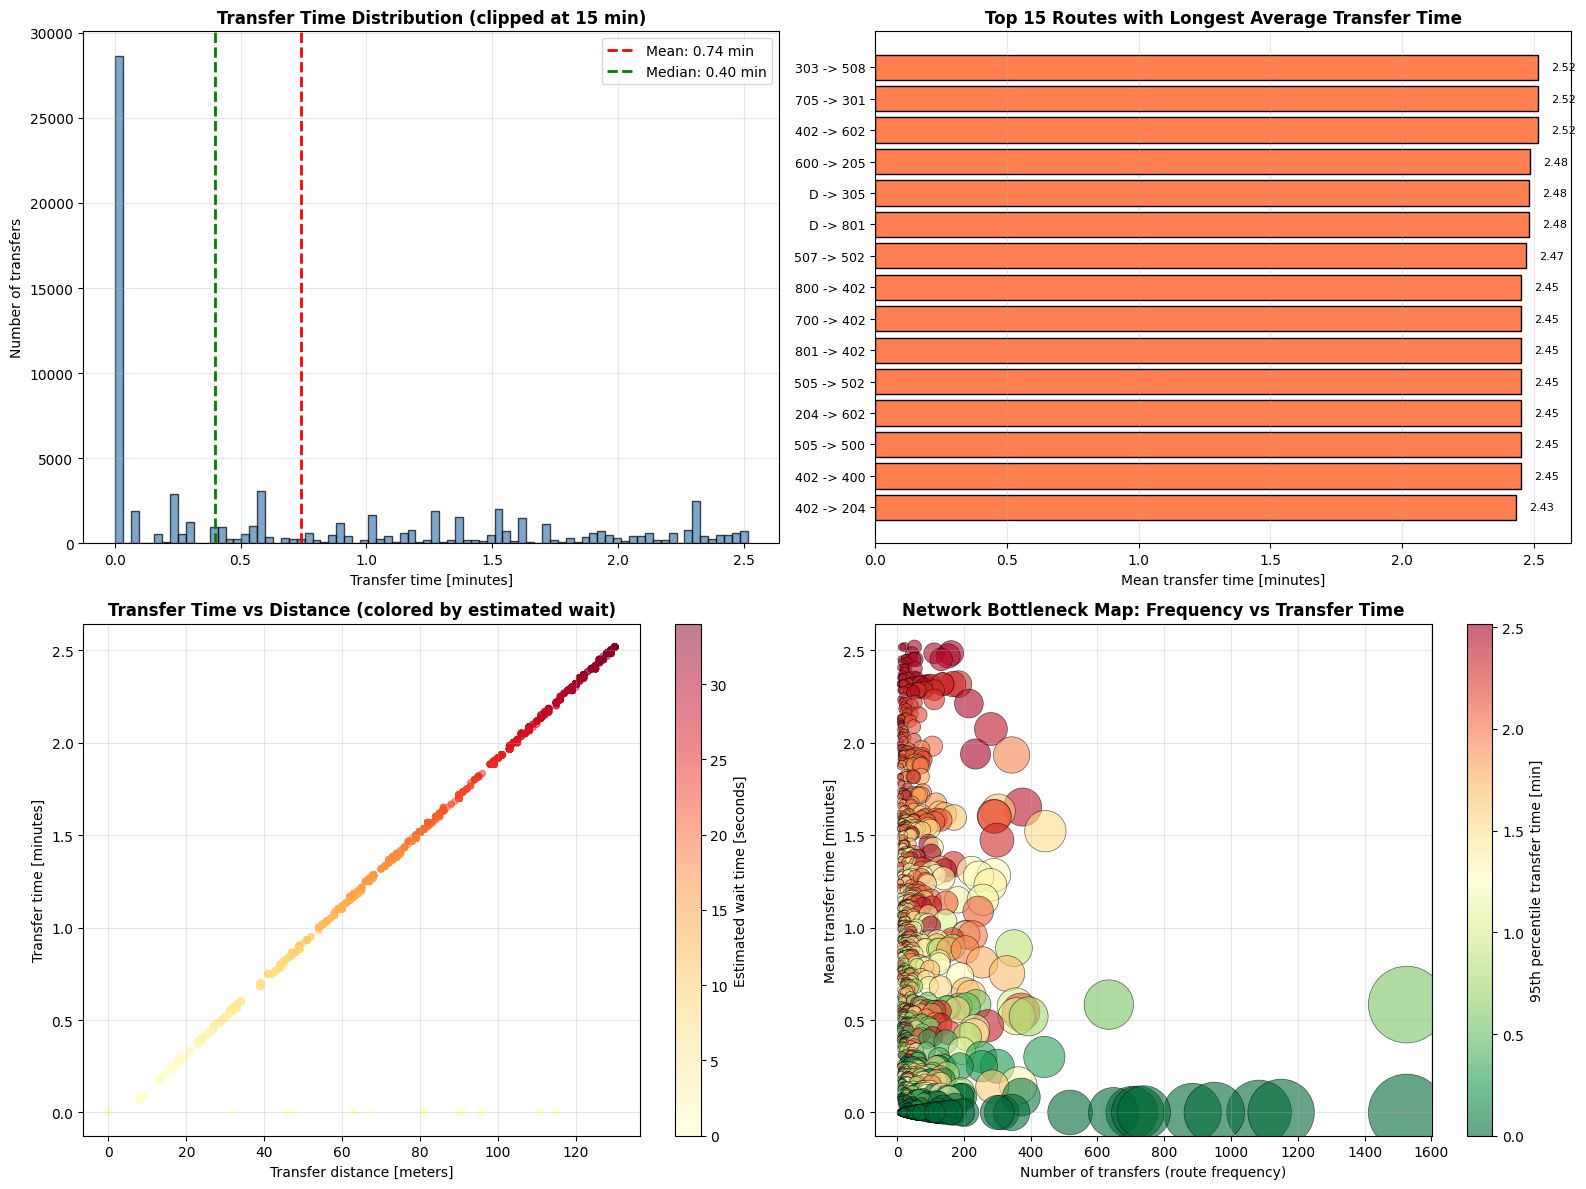

Visualization shows: (1) overall transfer time distribution, (2) worst routes by mean transfer time,
(3) relationship between distance and transfer time, (4) network bottlenecks by frequency and severity.


In [20]:
# Network bottleneck visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Chart 1: Transfer time distribution
transfer_time_min = transfers_realistic['transfer_time_s'] / 60
axes[0, 0].hist(transfer_time_min.clip(upper=15), bins=80, edgecolor='black', alpha=0.7, color='steelblue')
axes[0, 0].axvline(transfer_time_min.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {transfer_time_min.mean():.2f} min')
axes[0, 0].axvline(transfer_time_min.median(), color='green', linestyle='--', linewidth=2, label=f'Median: {transfer_time_min.median():.2f} min')
axes[0, 0].set_title('Transfer Time Distribution (clipped at 15 min)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Transfer time [minutes]')
axes[0, 0].set_ylabel('Number of transfers')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Chart 2: Top 15 routes by mean transfer time
top_routes_transfer = realistic_line_transfers[realistic_line_transfers['transfer_count'] >= 10].head(15).copy()
top_routes_transfer = top_routes_transfer.sort_values('mean_transfer_time_s', ascending=True)
axes[0, 1].barh(range(len(top_routes_transfer)), top_routes_transfer['mean_transfer_time_s']/60, color='coral', edgecolor='black')
axes[0, 1].set_yticks(range(len(top_routes_transfer)))
axes[0, 1].set_yticklabels(top_routes_transfer['transfer_route'], fontsize=9)
axes[0, 1].set_xlabel('Mean transfer time [minutes]')
axes[0, 1].set_title('Top 15 Routes with Longest Average Transfer Time', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_routes_transfer['mean_transfer_time_s']/60):
    axes[0, 1].text(v + 0.05, i, f'{v:.2f}', va='center', fontsize=8)

# Chart 3: Transfer time vs distance (scatter plot)
sample_data = transfers_realistic.sample(min(5000, len(transfers_realistic)))
scatter = axes[1, 0].scatter(sample_data['transfer_distance_m'], sample_data['transfer_time_s']/60,
                             c=sample_data['estimated_wait_time_s'], cmap='YlOrRd', alpha=0.5, s=20)
axes[1, 0].set_xlabel('Transfer distance [meters]')
axes[1, 0].set_ylabel('Transfer time [minutes]')
axes[1, 0].set_title('Transfer Time vs Distance (colored by estimated wait)', fontsize=12, fontweight='bold')
cbar = plt.colorbar(scatter, ax=axes[1, 0])
cbar.set_label('Estimated wait time [seconds]')
axes[1, 0].grid(alpha=0.3)

# Chart 4: Transfer count by route (bubble chart of frequency vs transfer time)
bubbles = realistic_line_transfers[realistic_line_transfers['transfer_count'] >= 10].copy()
axes[1, 1].scatter(bubbles['transfer_count'], bubbles['mean_transfer_time_s']/60,
                   s=bubbles['transfer_count']*2, alpha=0.6, c=bubbles['p95_transfer_time_s']/60,
                   cmap='RdYlGn_r', edgecolors='black', linewidth=0.5)
axes[1, 1].set_xlabel('Number of transfers (route frequency)')
axes[1, 1].set_ylabel('Mean transfer time [minutes]')
axes[1, 1].set_title('Network Bottleneck Map: Frequency vs Transfer Time', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)
cbar2 = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar2.set_label('95th percentile transfer time [min]')

plt.tight_layout()
plt.show()

print('Visualization shows: (1) overall transfer time distribution, (2) worst routes by mean transfer time,')
print('(3) relationship between distance and transfer time, (4) network bottlenecks by frequency and severity.')